
# EXPERIMENT-6: Language Processor
## N-Gram Language Model and Smoothing

**Objective:**  
Implement a statistical N-Gram Language Model using a text corpus and demonstrate:
1. Corpus loading and preprocessing
2. Unigram, Bigram and Trigram generation
3. Maximum Likelihood Estimation (MLE)
4. Add-One (Laplace) smoothing
5. Sentence probability
6. Perplexity
7. Comparison of unsmoothed and smoothed probabilities

**Dataset:** English News — Sentence Corpus from Kaggle. The Kaggle dataset contains English news sentences and provides an `all_news_sentences.txt` file that is convenient for language-model experiments. citeturn0search3

> **Instructor note:** The notebook intentionally uses a small sample of the downloaded corpus by default so that students can run the experiment on ordinary lab computers. The sample size can be increased later.



## 1. Background

An **N-Gram language model** estimates the probability of a word from the previous `N-1` words.

For a bigram model:

\[
P(w_1,w_2,\ldots,w_m) \approx \prod_{i=1}^{m} P(w_i|w_{i-1})
\]

For a trigram model:

\[
P(w_1,w_2,\ldots,w_m) \approx \prod_{i=1}^{m} P(w_i|w_{i-2},w_{i-1})
\]

### Why smoothing?

If an N-Gram never occurs in the training corpus, its MLE probability becomes zero. This makes the probability of the entire sentence zero.

**Laplace/Add-One smoothing** avoids zero probabilities:

\[
P_{Laplace}(w|h)=\frac{C(h,w)+1}{C(h)+V}
\]

where:
- `C(h,w)` = count of the N-Gram
- `C(h)` = count of the history
- `V` = vocabulary size


In [ ]:

# Install required packages if needed
!pip -q install kagglehub nltk pandas matplotlib


In [ ]:

import os
import re
import math
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Download the Kaggle Dataset
The following cell downloads the Kaggle dataset using `kagglehub`. If Kaggle asks for authentication, configure your Kaggle credentials first.

In [ ]:

# Kaggle dataset used for this experiment
DATASET_HANDLE = "ffatty/english-news-sentence-corpus"

dataset_path = kagglehub.dataset_download(DATASET_HANDLE)
print("Dataset downloaded to:")
print(dataset_path)

# Display downloaded files
for root, dirs, files in os.walk(dataset_path):
    for file in files[:10]:
        print(os.path.join(root, file))


100%|██████████| 976M/976M [00:10<00:00, 95.1MB/s]

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/ffatty/english-news-sentence-corpus/versions/1
/root/.cache/kagglehub/datasets/ffatty/english-news-sentence-corpus/versions/1/all_news_sentences.txt
/root/.cache/kagglehub/datasets/ffatty/english-news-sentence-corpus/versions/1/news_sentences/eng_newscrawl_sentences_2018.txt
/root/.cache/kagglehub/datasets/ffatty/english-news-sentence-corpus/versions/1/news_sentences/eng_news_sentences_2005.txt
/root/.cache/kagglehub/datasets/ffatty/english-news-sentence-corpus/versions/1/news_sentences/eng_news_sentences_2017.txt
/root/.cache/kagglehub/datasets/ffatty/english-news-sentence-corpus/versions/1/news_sentences/eng_news_sentences_2006.txt
/root/.cache/kagglehub/datasets/ffatty/english-news-sentence-corpus/versions/1/news_sentences/eng_news_sentences_2018.txt
/root/.cache/kagglehub/datasets/ffatty/english-news-sentence-corpus/versions/1/news_sentences/eng_news_sentences_2023.txt
/root/.cache/kagglehub/datasets/ffatty/english-news-sentenc

In [ ]:

# Locate the main text file automatically
candidate_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower() in {
            "all_news_sentences.txt",
            "news_sentences.txt",
            "sentences.txt"
        }:
            candidate_files.append(os.path.join(root, file))

if not candidate_files:
    # fallback: choose a reasonably large .txt file
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(".txt"):
                candidate_files.append(os.path.join(root, file))

if not candidate_files:
    raise FileNotFoundError("No suitable .txt corpus file was found.")

CORPUS_FILE = candidate_files[0]
print("Using corpus:", CORPUS_FILE)


Using corpus: /root/.cache/kagglehub/datasets/ffatty/english-news-sentence-corpus/versions/1/all_news_sentences.txt



## 3. Load and Inspect the Corpus

For a classroom demonstration, we use a configurable number of sentences. This keeps training fast while allowing students to increase the corpus later.


In [ ]:

MAX_SENTENCES = 10000   # Increase to 25,000 / 50,000 for a larger experiment

with open(CORPUS_FILE, "r", encoding="utf-8", errors="ignore") as f:
    raw_lines = [line.strip() for line in f if line.strip()]

random.seed(42)
random.shuffle(raw_lines)
sentences = raw_lines[:MAX_SENTENCES]

print("Number of sentences used:", len(sentences))
print("\nSample sentences:")
for s in sentences[:5]:
    print("-", s[:200])


Number of sentences used: 10000

Sample sentences:
- 350020	In 2016, the St. Patrick's Island took top honours in the Great Public Space category in the Canadian Institute of Planners' Great Places in Canada competition.
- 458926	Kyle Feldt bombed a certain try off a Thurston kick not long after.
- 589179	Has Iraq improved since the war?
- 234397	There is no reason to assume that water would cause more warfare than oil or national pride.
- 507714	Next, inventories are falling.



## 4. Text Preprocessing

We:
- convert text to lowercase
- retain alphabetic words and simple apostrophes
- add `<s>` and `</s>` sentence boundary tokens

The boundary tokens allow the language model to learn which words commonly start and end sentences.


In [ ]:

def tokenize_sentence(sentence):
    sentence = sentence.lower()
    tokens = re.findall(r"[a-z]+(?:'[a-z]+)?", sentence)
    return ["<s>"] + tokens + ["</s>"]

tokenized_sentences = [tokenize_sentence(s) for s in sentences]

# Remove extremely short/empty sentences
tokenized_sentences = [s for s in tokenized_sentences if len(s) >= 3]

print("Usable sentences:", len(tokenized_sentences))
print("Example tokens:", tokenized_sentences[0])


Usable sentences: 10000
Example tokens: ['<s>', 'in', 'the', 'st', "patrick's", 'island', 'took', 'top', 'honours', 'in', 'the', 'great', 'public', 'space', 'category', 'in', 'the', 'canadian', 'institute', 'of', 'planners', 'great', 'places', 'in', 'canada', 'competition', '</s>']


In [ ]:

# Train/test split
random.seed(42)
random.shuffle(tokenized_sentences)

split = int(0.8 * len(tokenized_sentences))
train_sentences = tokenized_sentences[:split]
test_sentences = tokenized_sentences[split:]

print("Training sentences:", len(train_sentences))
print("Testing sentences :", len(test_sentences))

# Vocabulary from training data
vocab = set()
for sent in train_sentences:
    vocab.update(sent)

# Add unknown token
vocab.add("<UNK>")

print("Vocabulary size:", len(vocab))


Training sentences: 8000
Testing sentences : 2000
Vocabulary size: 20227


## 5. Build N-Grams

In [ ]:

def generate_ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def build_ngram_counts(sentences, n):
    counts = Counter()
    for sent in sentences:
        counts.update(generate_ngrams(sent, n))
    return counts

unigram_counts = build_ngram_counts(train_sentences, 1)
bigram_counts = build_ngram_counts(train_sentences, 2)
trigram_counts = build_ngram_counts(train_sentences, 3)

print("Unique unigrams :", len(unigram_counts))
print("Unique bigrams  :", len(bigram_counts))
print("Unique trigrams :", len(trigram_counts))


Unique unigrams : 20226
Unique bigrams  : 101579
Unique trigrams : 142959


In [ ]:

def show_top_ngrams(counter, n=10):
    rows = []
    for gram, count in counter.most_common(n):
        rows.append((" ".join(gram), count))
    return pd.DataFrame(rows, columns=["N-Gram", "Count"])

print("Top Bigrams")
display(show_top_ngrams(bigram_counts, 10))

print("Top Trigrams")
display(show_top_ngrams(trigram_counts, 10))


Top Bigrams


,N-Gram,Count
0,of the,949
1,<s> the,945
2,in the,880
3,to the,428
4,on the,346
5,for the,308
6,at the,297
7,said </s>,276
8,<s> i,269
9,and the,249


Top Trigrams


,N-Gram,Count
0,one of the,66
1,<s> it s,55
2,he said </s>,52
3,<s> it was,45
4,<s> in the,44
5,a lot of,39
6,the u s,36
7,according to the,36
8,<s> it is,34
9,<s> but the,34



## 6. Maximum Likelihood Estimation (MLE)

For a bigram:

\[
P(w_i|w_{i-1}) = \frac{C(w_{i-1},w_i)}{C(w_{i-1})}
\]

For a trigram:

\[
P(w_i|w_{i-2},w_{i-1}) =
\frac{C(w_{i-2},w_{i-1},w_i)}
{C(w_{i-2},w_{i-1})}
\]


In [ ]:

def mle_bigram_probability(w1, w2):
    numerator = bigram_counts[(w1, w2)]
    denominator = unigram_counts[(w1,)]
    if denominator == 0:
        return 0.0
    return numerator / denominator

def mle_trigram_probability(w1, w2, w3):
    numerator = trigram_counts[(w1, w2, w3)]
    denominator = bigram_counts[(w1, w2)]
    if denominator == 0:
        return 0.0
    return numerator / denominator

examples = [
    ("the", "government"),
    ("machine", "learning"),
    ("new", "york")
]

for w1, w2 in examples:
    print(f"P({w2}|{w1}) =", mle_bigram_probability(w1, w2))


P(government|the) = 0.004648648648648649
P(learning|machine) = 0.0
P(york|new) = 0.1245674740484429



## 7. Demonstrate the Zero-Frequency Problem

A word sequence that was not observed receives probability `0` under ordinary MLE.

This is the motivation for smoothing.


In [ ]:

test_pairs = [
    ("xyzabc", "qwerty"),
    ("machine", "learning"),
    ("the", "government")
]

for w1, w2 in test_pairs:
    print(f"P({w2}|{w1}) = {mle_bigram_probability(w1, w2)}")


P(qwerty|xyzabc) = 0.0
P(learning|machine) = 0.0
P(government|the) = 0.004648648648648649



## 8. Add-One / Laplace Smoothing

For a bigram:

\[
P_{Laplace}(w_i|w_{i-1}) =
\frac{C(w_{i-1},w_i)+1}
{C(w_{i-1})+V}
\]

For a trigram:

\[
P_{Laplace}(w_i|w_{i-2},w_{i-1}) =
\frac{C(w_{i-2},w_{i-1},w_i)+1}
{C(w_{i-2},w_{i-1})+V}
\]


In [ ]:

V = len(vocab)

def laplace_bigram_probability(w1, w2):
    count_bigram = bigram_counts[(w1, w2)]
    count_history = unigram_counts[(w1,)]
    return (count_bigram + 1) / (count_history + V)

def laplace_trigram_probability(w1, w2, w3):
    count_trigram = trigram_counts[(w1, w2, w3)]
    count_history = bigram_counts[(w1, w2)]
    return (count_trigram + 1) / (count_history + V)

for w1, w2 in test_pairs:
    print(f"Laplace P({w2}|{w1}) = {laplace_bigram_probability(w1, w2):.10f}")


Laplace P(qwerty|xyzabc) = 0.0000494389
Laplace P(learning|machine) = 0.0000494291
Laplace P(government|the) = 0.0014926892


## 9. Sentence Probability
We calculate the probability of a sentence using a bigram model.

In [ ]:

def normalize_for_vocab(tokens):
    return [token if token in vocab else "<UNK>" for token in tokens]

def sentence_probability_bigram(sentence, smoothing=False):
    tokens = normalize_for_vocab(tokenize_sentence(sentence))
    log_probability = 0.0

    for i in range(1, len(tokens)):
        w1, w2 = tokens[i-1], tokens[i]

        if smoothing:
            p = laplace_bigram_probability(w1, w2)
        else:
            p = mle_bigram_probability(w1, w2)

        if p == 0:
            return 0.0

        log_probability += math.log(p)

    return math.exp(log_probability)

sample_sentence = "machine learning is useful"

print("Sentence:", sample_sentence)
print("MLE probability:", sentence_probability_bigram(sample_sentence, smoothing=False))
print("Laplace probability:", sentence_probability_bigram(sample_sentence, smoothing=True))


Sentence: machine learning is useful
MLE probability: 0.0
Laplace probability: 3.9365508511615806e-22



## 10. Perplexity

Perplexity measures how well a language model predicts a sequence.

For a sequence of `N` predicted words:

\[
PP(W)=P(w_1,w_2,...,w_N)^{-1/N}
\]

In practice, log probabilities are used to avoid numerical underflow:

\[
PP(W)=\exp\left(-\frac{1}{N}\sum_i \log P(w_i|h_i)\right)
\]

Lower perplexity means the model assigns higher probability to the observed test sequence. It should be interpreted only within comparable experiments using the same evaluation data.


In [ ]:

def perplexity_bigram(test_data, smoothing=True):
    total_log_prob = 0.0
    total_predictions = 0

    for sentence in test_data:
        tokens = normalize_for_vocab(sentence)

        for i in range(1, len(tokens)):
            w1, w2 = tokens[i-1], tokens[i]

            if smoothing:
                p = laplace_bigram_probability(w1, w2)
            else:
                p = mle_bigram_probability(w1, w2)

            if p <= 0:
                return float("inf")

            total_log_prob += math.log(p)
            total_predictions += 1

    return math.exp(-total_log_prob / total_predictions)

print("Laplace-smoothed bigram perplexity:",
      perplexity_bigram(test_sentences, smoothing=True))

print("Unsmoothed bigram perplexity:",
      perplexity_bigram(test_sentences, smoothing=False))


Laplace-smoothed bigram perplexity: 6962.942964415433
Unsmoothed bigram perplexity: inf



## 11. Compare Smoothing on Different Sentence Examples


In [ ]:

evaluation_sentences = [
    "the government announced a new policy",
    "machine learning is used in many applications",
    "artificial intelligence is changing technology",
    "the quick brown fox jumps over the lazy dog"
]

results = []

for sentence in evaluation_sentences:
    mle = sentence_probability_bigram(sentence, smoothing=False)
    laplace = sentence_probability_bigram(sentence, smoothing=True)

    results.append({
        "Sentence": sentence,
        "MLE Probability": mle,
        "Laplace Probability": laplace
    })

results_df = pd.DataFrame(results)
display(results_df)


,Sentence,MLE Probability,Laplace Probability
0,the government announced a new policy,0.0,1.190597e-23
1,machine learning is used in many applications,0.0,2.526705e-32
2,artificial intelligence is changing technology,0.0,2.333117e-25
3,the quick brown fox jumps over the lazy dog,0.0,3.461920e-39



## 12. Optional: Generate a Next-Word Prediction

A simple bigram model can predict the next word by selecting the word with the highest estimated conditional probability.

This is a basic demonstration of how statistical language models can support next-word prediction.


In [ ]:

def predict_next_word(previous_word, top_k=10):
    previous_word = previous_word.lower()

    candidates = []
    denominator = unigram_counts[(previous_word,)]

    if denominator == 0:
        return pd.DataFrame(columns=["Next Word", "Probability"])

    for (w1, w2), count in bigram_counts.items():
        if w1 == previous_word:
            candidates.append((w2, count / denominator))

    candidates.sort(key=lambda x: x[1], reverse=True)

    return pd.DataFrame(
        candidates[:top_k],
        columns=["Next Word", "Probability"]
    )

display(predict_next_word("machine", 10))


,Next Word,Probability
0,pitch,0.25
1,mdash,0.25
2,a,0.25
3,that,0.25



## 13. Visualization of Frequent Bigrams


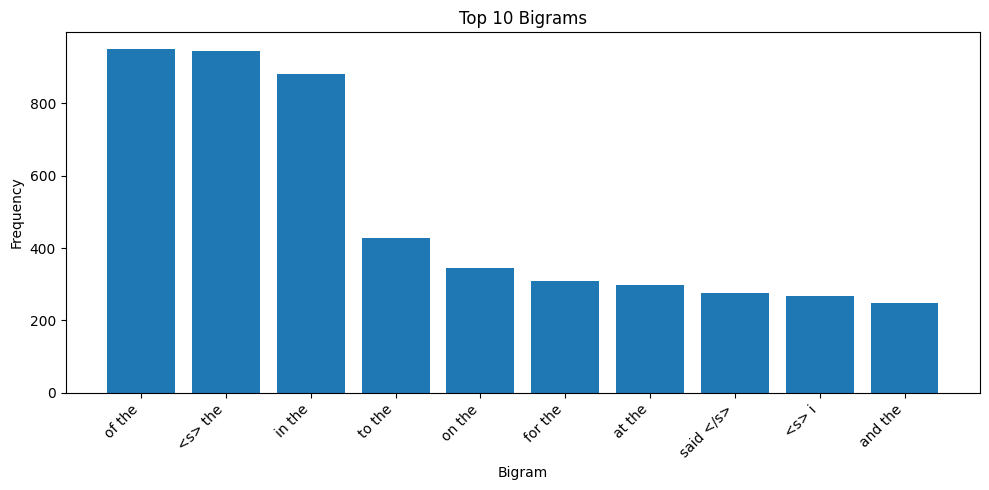

In [ ]:

top10 = bigram_counts.most_common(10)
labels = [" ".join(g) for g, _ in top10]
values = [c for _, c in top10]

plt.figure(figsize=(10, 5))
plt.bar(labels, values)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Bigram")
plt.ylabel("Frequency")
plt.title("Top 10 Bigrams")
plt.tight_layout()
plt.show()



# 14. Student Tasks

### Task 1
Change the experiment from a **bigram** model to a **trigram** model.

### Task 2
Calculate the probability of a sentence using the trigram model.

### Task 3
Compare MLE and Laplace smoothing for the trigram model.

### Task 4
Change the value of `MAX_SENTENCES` and observe how vocabulary size and perplexity change.

### Task 5
Implement **Add-k smoothing**:

\[
P(w|h)=\frac{C(h,w)+k}{C(h)+kV}
\]

Try `k = 0.1`, `0.5`, and `1.0`.

### Task 6
Implement a function:

`generate_text(start_word, number_of_words)`

that generates text using the bigram probabilities.

### Task 7 — Thinking Question
Why can increasing the amount of training data reduce the number of unseen N-Grams, but still not completely solve the zero-frequency problem?



# 15. Viva Questions

1. What is an N-Gram?
2. What is the difference between unigram, bigram and trigram models?
3. Why are `<s>` and `</s>` used?
4. What is Maximum Likelihood Estimation in an N-Gram model?
5. What is the zero-frequency problem?
6. Why is smoothing required?
7. What is Add-One/Laplace smoothing?
8. What does `V` represent in the Laplace equation?
9. What is perplexity?
10. Why do we normally use log probabilities when calculating sentence probability?
11. What happens when an unseen bigram occurs in an unsmoothed model?
12. What is the difference between training corpus vocabulary and test vocabulary?
13. How does an N-Gram model perform next-word prediction?
14. What is the limitation of a fixed-order N-Gram model?
15. How could you improve this experiment using Good-Turing, Kneser-Ney or interpolation?



## Expected Learning Outcomes

After completing this experiment, students should be able to:

- construct unigram, bigram and trigram language models;
- estimate conditional word probabilities;
- explain and implement Laplace smoothing;
- identify the zero-frequency problem;
- calculate sentence probability;
- calculate perplexity;
- use an N-Gram model for basic next-word prediction; and
- explain the limitations of traditional statistical language models.

### Dataset reference

The selected Kaggle dataset is **English News — Sentence Corpus**, which contains a large collection of English news sentences and an `all_news_sentences.txt` file. citeturn0search3
